![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Proyecto 2 - Clasificación de género de películas

El propósito de este proyecto es que puedan poner en práctica, en sus respectivos grupos de trabajo, sus conocimientos sobre técnicas de preprocesamiento, modelos predictivos de NLP, y la disponibilización de modelos. Para su desarrollo tengan en cuenta las instrucciones dadas en la "Guía del proyecto 2: Clasificación de género de películas"

**Entrega**: La entrega del proyecto deberán realizarla durante la semana 8. Sin embargo, es importante que avancen en la semana 7 en el modelado del problema y en parte del informe, tal y como se les indicó en la guía.

Para hacer la entrega, deberán adjuntar el informe autocontenido en PDF a la actividad de entrega del proyecto que encontrarán en la semana 8, y subir el archivo de predicciones a la [competencia de Kaggle](https://www.kaggle.com/t/29c44fce98c747f2a1dfdaf29d4c4965).

## Datos para la predicción de género en películas

![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/moviegenre.png)

En este proyecto se usará un conjunto de datos de géneros de películas. Cada observación contiene el título de una película, su año de lanzamiento, la sinopsis o plot de la película (resumen de la trama) y los géneros a los que pertenece (una película puede pertenercer a más de un género). Por ejemplo:
- Título: 'How to Be a Serial Killer'
- Plot: 'A serial killer decides to teach the secrets of his satisfying career to a video store clerk.'
- Generos: 'Comedy', 'Crime', 'Horror'

La idea es que usen estos datos para predecir la probabilidad de que una película pertenezca, dada la sinopsis, a cada uno de los géneros.

Agradecemos al profesor Fabio González, Ph.D. y a su alumno John Arevalo por proporcionar este conjunto de datos. Ver https://arxiv.org/abs/1702.01992

## Ejemplo predicción conjunto de test para envío a Kaggle
En esta sección encontrarán el formato en el que deben guardar los resultados de la predicción para que puedan subirlos a la competencia en Kaggle.

In [32]:
import warnings
warnings.filterwarnings('ignore')

In [33]:
# Importación librerías
import pandas as pd
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import joblib
%matplotlib inline

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

import seaborn as sns
from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer

In [34]:
# Carga de datos de archivo .csv
dataTraining = pd.read_csv('https://github.com/albahnsen/MIAD_ML_and_NLP/raw/main/datasets/dataTraining.zip', encoding='UTF-8', index_col=0)
dataTesting = pd.read_csv('https://github.com/albahnsen/MIAD_ML_and_NLP/raw/main/datasets/dataTesting.zip', encoding='UTF-8', index_col=0)

In [35]:
# Visualización datos de entrenamiento
dataTraining.head()

,year,title,plot,genres,rating
3107,2003,Most,most is the story of a single father who takes...,"['Short', 'Drama']",8.0
900,2008,How to Be a Serial Killer,a serial killer decides to teach the secrets o...,"['Comedy', 'Crime', 'Horror']",5.6
6724,1941,A Woman's Face,"in sweden , a female blackmailer with a disfi...","['Drama', 'Film-Noir', 'Thriller']",7.2
4704,1954,Executive Suite,"in a friday afternoon in new york , the presi...",['Drama'],7.4
2582,1990,Narrow Margin,"in los angeles , the editor of a publishing h...","['Action', 'Crime', 'Thriller']",6.6


In [36]:
# Visualización datos de test
dataTesting.head()

,year,title,plot
1,1999,Message in a Bottle,"who meets by fate , shall be sealed by fate ...."
4,1978,Midnight Express,"the true story of billy hayes , an american c..."
5,1996,Primal Fear,martin vail left the chicago da ' s office to ...
6,1950,Crisis,husband and wife americans dr . eugene and mr...
7,1959,The Tingler,the coroner and scientist dr . warren chapin ...


## 1. Análisis Exploratorio (EDA)

Antes de modelar, revisamos la distribución de géneros, el balance de clases y la longitud de los plots.

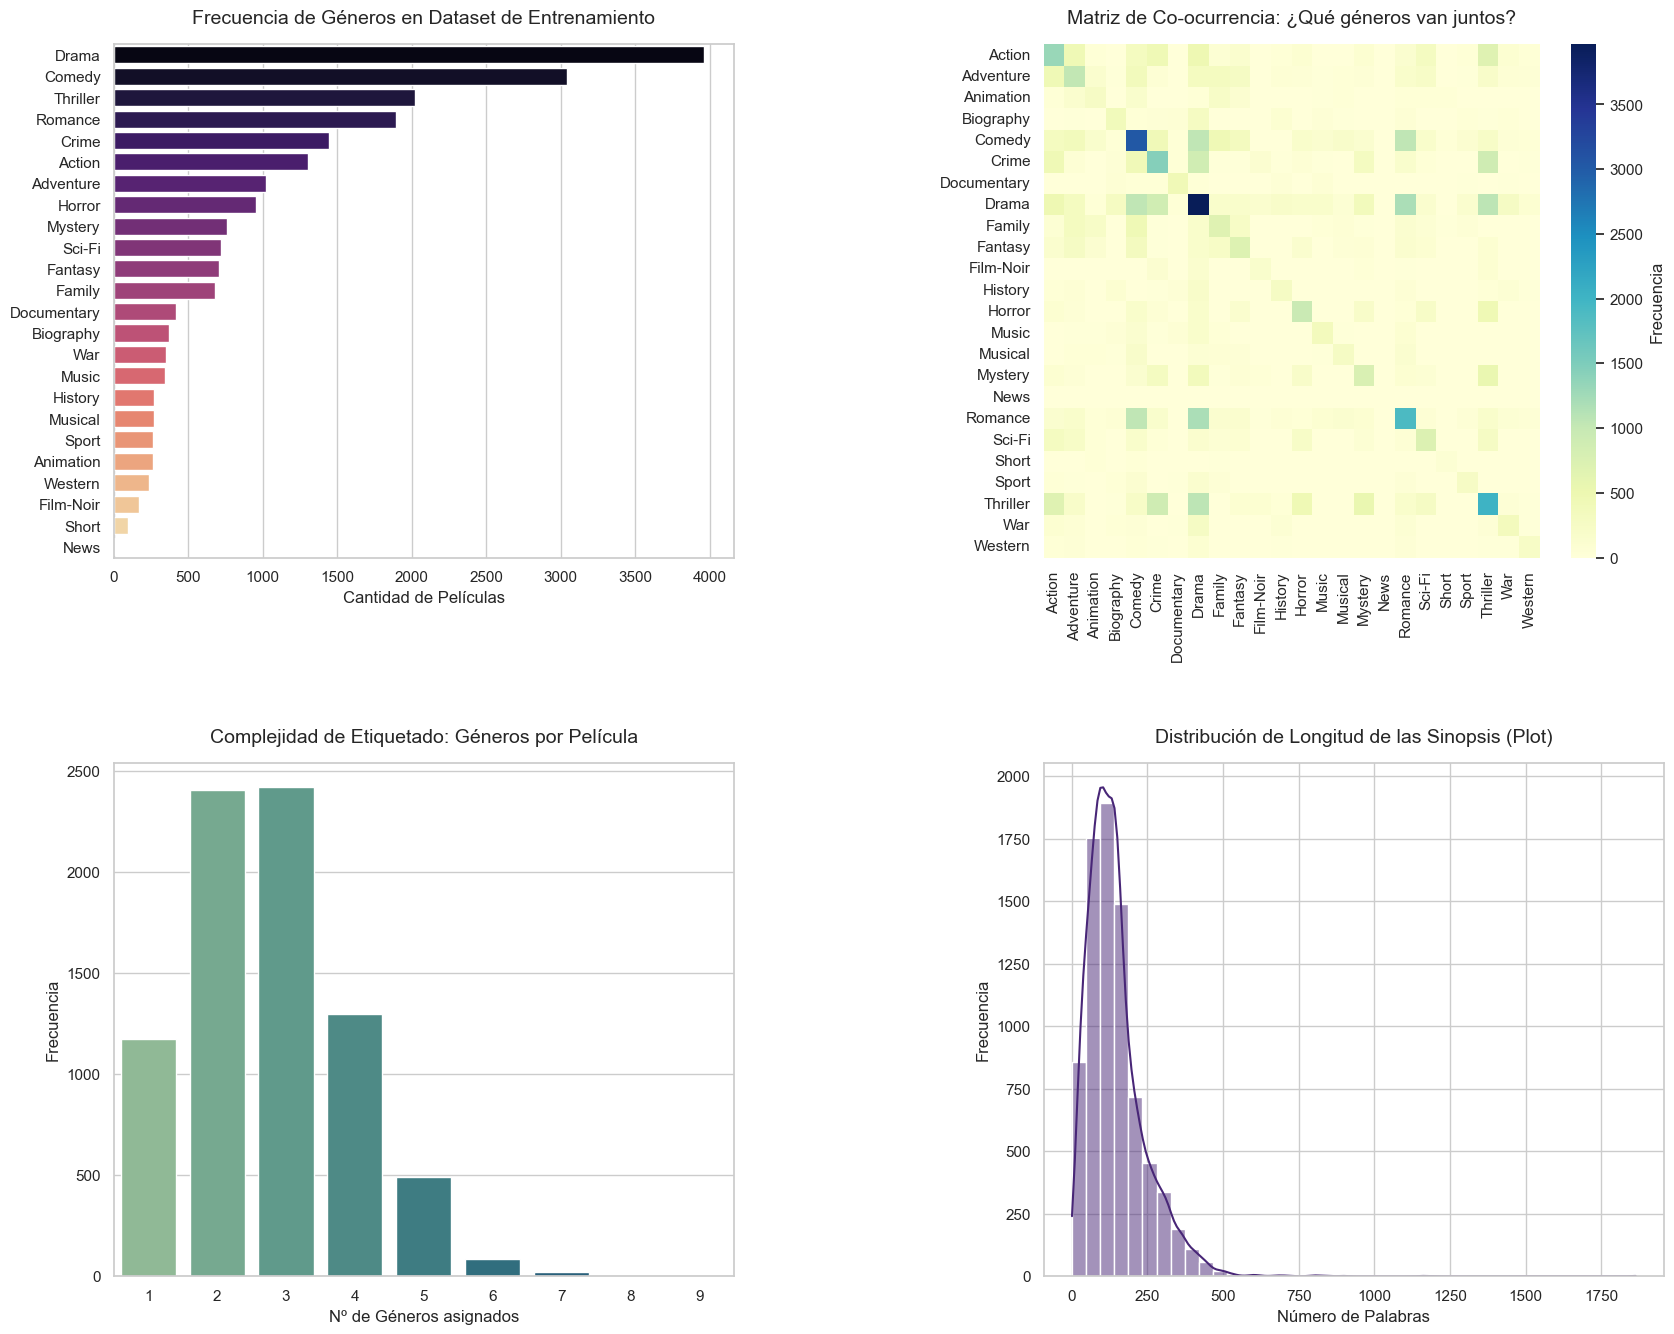

--------------------------------------------------
RESUMEN DESCRIPTIVO DEL DATASET
--------------------------------------------------
Total de películas analizadas:      7,895
Géneros únicos identificados:       24
Longitud promedio del plot:         144.8 palabras
Máxima cantidad de géneros/película: 9
Género más frecuente:               Drama (3965 apariciones)
--------------------------------------------------

Top 5 Géneros más comunes:
  • Drama           |  3965 films ( 50.2%)
  • Comedy          |  3046 films ( 38.6%)
  • Thriller        |  2024 films ( 25.6%)
  • Romance         |  1892 films ( 24.0%)
  • Crime           |  1447 films ( 18.3%)
--------------------------------------------------


In [37]:
sns.set_theme(style="whitegrid")
palette = sns.color_palette("viridis", as_cmap=False)

dataTraining['genres_list'] = dataTraining['genres'].map(lambda x: eval(x))
dataTraining = dataTraining.drop('genres', axis=1)

genre_counts = Counter(g for genres in dataTraining['genres_list'] for g in genres)
genre_df = pd.DataFrame(genre_counts.most_common(), columns=['genre', 'count'])
plot_lengths = dataTraining['plot'].str.split().map(len)
genres_per_movie = dataTraining['genres_list'].map(len)

fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.5)

# A. FRECUENCIA DE GÉNEROS (Horizontal por legibilidad)
ax1 = fig.add_subplot(gs[0, 0])
sns.barplot(data=genre_df, x='count', y='genre', ax=ax1, palette="magma")
ax1.set_title("Frecuencia de Géneros en Dataset de Entrenamiento", fontsize=14, pad=15)
ax1.set_xlabel("Cantidad de Películas")
ax1.set_ylabel("")

# B. MATRIZ DE CO-OCURRENCIA 
ax2 = fig.add_subplot(gs[0, 1])
# Crear matriz de ceros y unos para calcular co-ocurrencia
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
genre_matrix = pd.DataFrame(mlb.fit_transform(dataTraining['genres_list']), columns=mlb.classes_)
co_occurrence = genre_matrix.T.dot(genre_matrix)
sns.heatmap(co_occurrence, ax=ax2, cmap="YlGnBu", cbar_kws={'label': 'Frecuencia'})
ax2.set_title("Matriz de Co-ocurrencia: ¿Qué géneros van juntos?", fontsize=14, pad=15)

# C. DISTRIBUCIÓN: GÉNEROS POR PELÍCULA
ax3 = fig.add_subplot(gs[1, 0])
sns.countplot(x=genres_per_movie, ax=ax3, palette="crest")
ax3.set_title("Complejidad de Etiquetado: Géneros por Película", fontsize=14, pad=15)
ax3.set_xlabel("Nº de Géneros asignados")
ax3.set_ylabel("Frecuencia")

# D. LONGITUD DEL PLOT
ax4 = fig.add_subplot(gs[1, 1])
sns.histplot(plot_lengths, bins=40, kde=True, ax=ax4, color="#482677")
ax4.set_title("Distribución de Longitud de las Sinopsis (Plot)", fontsize=14, pad=15)
ax4.set_xlabel("Número de Palabras")
ax4.set_ylabel("Frecuencia")

plt.show()

# --- IMPRESIÓN DEL RESUMEN ESTADÍSTICO ---
print("-" * 50)
print("RESUMEN DESCRIPTIVO DEL DATASET")
print("-" * 50)
print(f"{'Total de películas analizadas:':<35} {len(dataTraining):,}")
print(f"{'Géneros únicos identificados:':<35} {len(genre_df)}")
print(f"{'Longitud promedio del plot:':<35} {plot_lengths.mean():.1f} palabras")
print(f"{'Máxima cantidad de géneros/película:':<35} {genres_per_movie.max()}")
print(f"{'Género más frecuente:':<35} {genre_df.iloc[0]['genre']} ({genre_df.iloc[0]['count']} apariciones)")
print("-" * 50)

# Opcional: Top 5 géneros más comunes
print("\nTop 5 Géneros más comunes:")
for i, row in genre_df.head(5).iterrows():
    percentage = (row['count'] / len(dataTraining)) * 100
    print(f"  • {row['genre']:<15} | {row['count']:>5} films ({percentage:>5.1f}%)")
print("-" * 50)

## 2. Ingeniería de Características (Feature Engineering)

Para enriquecer el modelo, se propone la creación de variables sintéticas que capturen matices semánticos y estructurales

In [ ]:
# Definición de variable de interés (y)
le = MultiLabelBinarizer()
y_genres = le.fit_transform(dataTraining['genres_list'])

# Separación de variables predictoras (X) y variable de interés (y) en set de entrenamiento y test usandola función train_test_split
X_train, X_val, y_train, y_val = train_test_split(dataTraining, y_genres, test_size=0.2, random_state=42)

In [ ]:
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer

# --- A. ANÁLISIS DE SENTIMIENTO ---
# Calculamos la polaridad (-1 a 1). 0 es neutro, 1 es muy positivo.
X_train['sentiment'] = X_train['plot'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
X_val['sentiment'] = X_val['plot'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# --- B. IDENTIFICACIÓN DE PALABRAS CLAVE (Keywords) ---
# Usamos TF-IDF para encontrar palabras con alto poder discriminatorio por género
# Aquí sí usamos un stop_words interno para no traer palabras como "the", "and", etc.
vectorizer = TfidfVectorizer(max_features=20, stop_words='english')
X_tfidf = vectorizer.fit_transform(X_train['plot'])
top_keywords = vectorizer.get_feature_names_out()
print("Palabras clave identificadas para nuevas columnas:", top_keywords)

# --- C. CREACIÓN DE COLUMNAS BINARIAS (Presencia/Ausencia) ---
# Iteramos sobre las palabras más comunes y creamos una columna por cada una
for word in top_keywords:
    col_name = f'has_{word}'
    # Buscamos la palabra exacta (usando \b para límites de palabra) en el texto original
    X_train[col_name] = X_train['plot'].str.contains(rf'\b{word}\b', case=False).astype(int)
    X_val[col_name] = X_val['plot'].str.contains(rf'\b{word}\b', case=False).astype(int)

Palabras clave identificadas para nuevas columnas: ['family' 'father' 'finds' 'friend' 'help' 'home' 'life' 'love' 'man'
 'mother' 'new' 'old' 'school' 'time' 'wants' 'way' 'wife' 'world' 'years'
 'young']


#

# 4. BERT

In [ ]:
pip install torch

In [52]:
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
import torch
from torch.utils.data import Dataset

# Definir el dispositivo (GPU si está disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


ModuleNotFoundError: No module named 'torch'

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_data(texts):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=128, # Ajustable según el promedio de palabras de tus plots
        return_tensors="pt"
    )

# Tokenizamos los conjuntos que ya dividiste (80/20)
X_train_BERT = tokenize_data(X_train['plot'])
X_val_BERT = tokenize_data(X_val['plot'])

In [ ]:
class MovieDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        # Convertimos las etiquetas a float para la función de pérdida (BCEWithLogitsLoss)
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = MovieDataset(train_encodings, y_train_genres)
val_dataset = MovieDataset(val_encodings, y_val_genres)

In [ ]:
num_labels = y_train_genres.shape[1] # Debería ser 24 según tus datos anteriores

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', 
    num_labels=num_labels,
    problem_type="multi_label_classification" # Configuración clave para multietiqueta
)
model.to(device)

In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,              # BERT suele converger rápido (2-4 épocas)
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    evaluation_strategy="epoch",      # Evaluar al final de cada época
    save_strategy="epoch",
    load_best_model_at_end=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

# ¡A entrenar!
trainer.train()